In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
print("="*80)
print("STEP 1: CLINICAL DATA GENERATION & PIPELINE SETUP")
print("="*80)

STEP 1: CLINICAL DATA GENERATION & PIPELINE SETUP


In [4]:
np.random.seed(42)
n_samples = 2500

In [5]:
data = {
    'Patient_ID': [f'PAT-{i:05d}' for i in range(1, n_samples + 1)],
    'Age': np.random.randint(18, 90, size=n_samples),
    'Gender': np.random.choice(['Male', 'Female'], size=n_samples, p=[0.48, 0.52]),
    'Admission_Type': np.random.choice(['Emergency', 'Urgent', 'Elective'], size=n_samples, p=[0.60, 0.25, 0.15]),
    'Length_of_Stay': np.random.geometric(p=0.2, size=n_samples) + 1,
    'Num_Lab_Procedures': np.random.randint(10, 100, size=n_samples),
    'Num_Medications': np.random.randint(1, 35, size=n_samples),
    'Num_Prior_Inpatient_Visits': np.random.poisson(lam=0.8, size=n_samples),
    'Num_Emergency_Visits': np.random.poisson(lam=0.5, size=n_samples),
    'Glucose_Test_Result': np.random.choice(['Normal', 'High', 'Very High'], size=n_samples, p=[0.70, 0.20, 0.10]),
    'HbA1c_Result': np.random.choice(['Normal', 'Elevated', 'High'], size=n_samples, p=[0.65, 0.25, 0.10]),
    'Comorbidities_Count': np.random.randint(0, 6, size=n_samples)
}

In [6]:
df = pd.DataFrame(data)

In [7]:
readmit_prob = (
    (df['Age'] > 65) * 0.15 +
    (df['Num_Prior_Inpatient_Visits'] * 0.12) +
    (df['Num_Emergency_Visits'] * 0.15) +
    (df['Length_of_Stay'] > 7) * 0.10 +
    (df['HbA1c_Result'] == 'High') * 0.18 +
    (df['Comorbidities_Count'] * 0.05) +
    (df['Admission_Type'] == 'Emergency') * 0.08
)

In [8]:
df['Readmitted'] = np.where(readmit_prob + np.random.normal(0, 0.15, n_samples) > 0.65, 1, 0)

In [9]:
print(f"Dataset generated successfully with {df.shape[0]} patient records and {df.shape[1]} clinical variables.\n")
print(df.head())

Dataset generated successfully with 2500 patient records and 13 clinical variables.

  Patient_ID  Age  Gender Admission_Type  Length_of_Stay  Num_Lab_Procedures  \
0  PAT-00001   69  Female      Emergency               8                  45   
1  PAT-00002   32  Female      Emergency              14                  60   
2  PAT-00003   89    Male       Elective              15                  10   
3  PAT-00004   78  Female      Emergency               4                  42   
4  PAT-00005   38    Male      Emergency               2                  16   

   Num_Medications  Num_Prior_Inpatient_Visits  Num_Emergency_Visits  \
0               20                           4                     0   
1               28                           3                     0   
2               14                           1                     2   
3               34                           0                     1   
4               13                           2                     0   

 

In [10]:
print("\n" + "="*80)
print("STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)


STEP 2: EXPLORATORY DATA ANALYSIS (EDA)


In [11]:
print(f"Target Distribution:\n{df['Readmitted'].value_counts(normalize=True) * 100}\n")

Target Distribution:
Readmitted
0    81.6
1    18.4
Name: proportion, dtype: float64



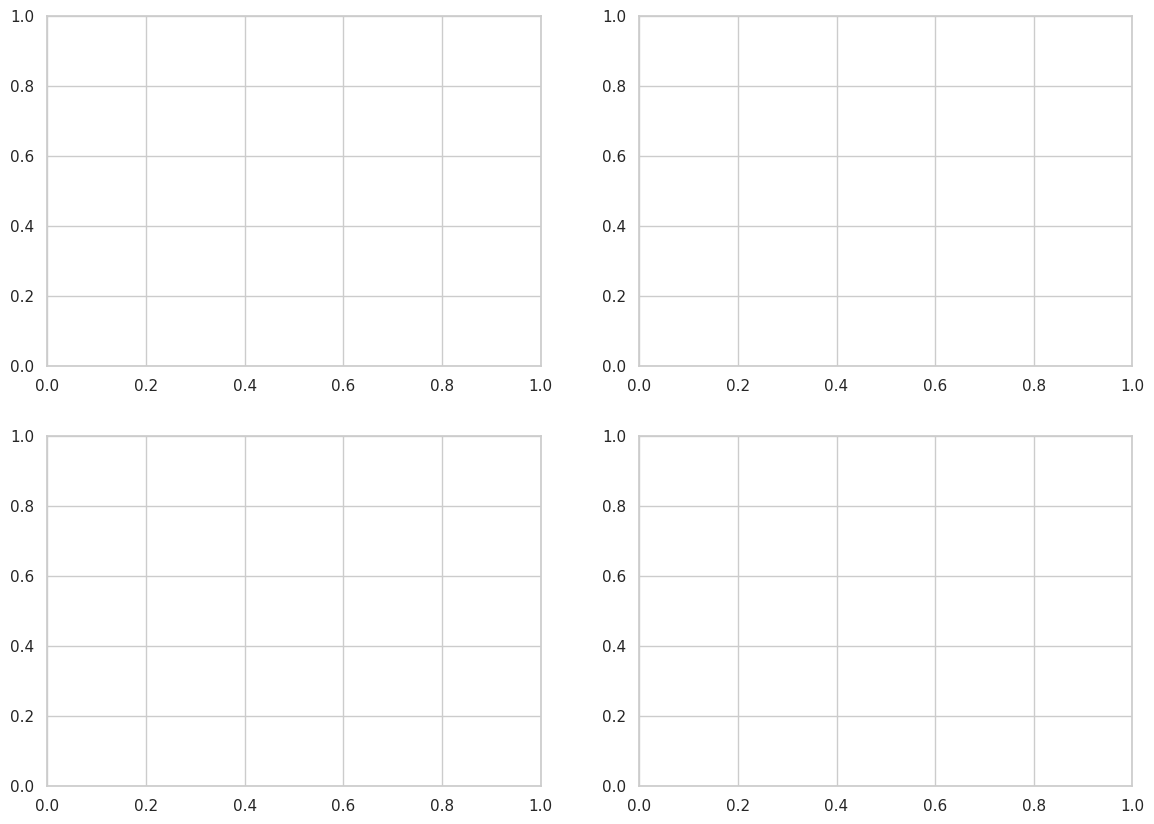

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [13]:
sns.countplot(data=df, x='Admission_Type', hue='Readmitted', ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('Readmission Distribution by Admission Type')

Text(0.5, 1.0, 'Readmission Distribution by Admission Type')

In [14]:
sns.boxplot(data=df, x='Readmitted', y='Age', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Patient Age Distribution vs Readmission Status')

/tmp/ipykernel_2220/1459215140.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Readmitted', y='Age', ax=axes[0, 1], palette='coolwarm')


Text(0.5, 1.0, 'Patient Age Distribution vs Readmission Status')

In [15]:
sns.barplot(data=df, x='Comorbidities_Count', y='Readmitted', ax=axes[1, 0], palette='Blues_d')
axes[1, 0].set_title('Readmission Probability by Comorbidities Count')

/tmp/ipykernel_2220/2606401773.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Comorbidities_Count', y='Readmitted', ax=axes[1, 0], palette='Blues_d')


Text(0.5, 1.0, 'Readmission Probability by Comorbidities Count')

In [16]:
sns.boxplot(data=df, x='Readmitted', y='Length_of_Stay', ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('Length of Stay (Days) vs Readmission Status')

/tmp/ipykernel_2220/1987707796.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Readmitted', y='Length_of_Stay', ax=axes[1, 1], palette='Purples')


Text(0.5, 1.0, 'Length of Stay (Days) vs Readmission Status')

In [17]:
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

In [18]:
print("\n" + "="*80)
print("STEP 3: FEATURE ENGINEERING & DATA PREPROCESSING")
print("="*80)


STEP 3: FEATURE ENGINEERING & DATA PREPROCESSING


In [19]:
X = df.drop(columns=['Patient_ID', 'Readmitted'])
y = df['Readmitted']

In [20]:
numeric_features = ['Age', 'Length_of_Stay', 'Num_Lab_Procedures', 'Num_Medications',
                    'Num_Prior_Inpatient_Visits', 'Num_Emergency_Visits', 'Comorbidities_Count']
categorical_features = ['Gender', 'Admission_Type', 'Glucose_Test_Result', 'HbA1c_Result']

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training Features Shape: {X_train_processed.shape}")
print(f"Testing Features Shape:  {X_test_processed.shape}")

Training Features Shape: (2000, 14)
Testing Features Shape:  (500, 14)


In [23]:
print("\n" + "="*80)
print("STEP 4: MODEL DEVELOPMENT & COMPARATIVE ANALYSIS")
print("="*80)


STEP 4: MODEL DEVELOPMENT & COMPARATIVE ANALYSIS


In [24]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Predictions": y_pred,
        "Probabilities": y_prob
    }

In [26]:
results_df = pd.DataFrame(results).T.iloc[:, :5]
print("\n--- MODEL PERFORMANCE COMPARISON ---")
print(results_df.to_string())


--- MODEL PERFORMANCE COMPARISON ---
                    Accuracy Precision    Recall  F1-Score   ROC-AUC
Logistic Regression    0.894      0.76  0.619565  0.682635  0.928629
Random Forest          0.864  0.772727  0.369565       0.5   0.91363
XGBoost                 0.87      0.68  0.554348  0.610778   0.91712


In [27]:
print("\n" + "="*80)
print("STEP 5: VISUAL EVALUATION & ROC CURVES")
print("="*80)


STEP 5: VISUAL EVALUATION & ROC CURVES


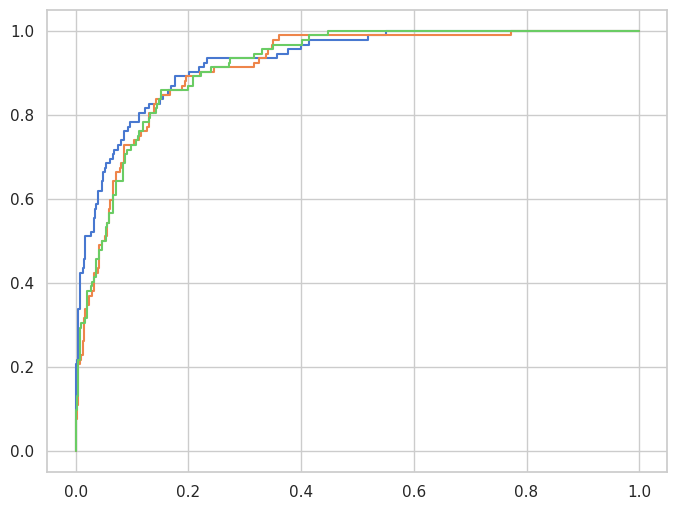

In [28]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, results[name]["Probabilities"])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.3f})')

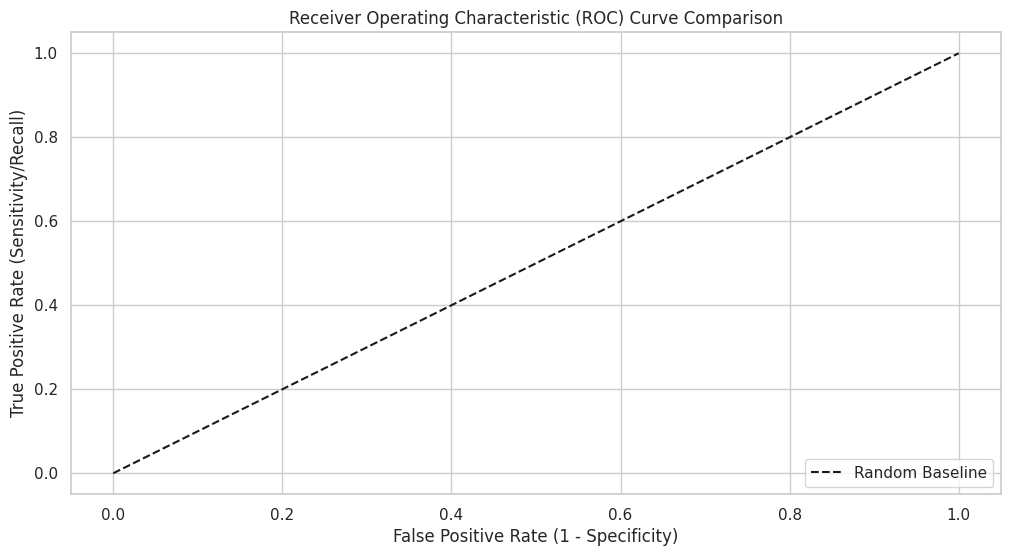

In [29]:
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.show()

In [30]:
best_model_name = "XGBoost"
cm = confusion_matrix(y_test, results[best_model_name]["Predictions"])

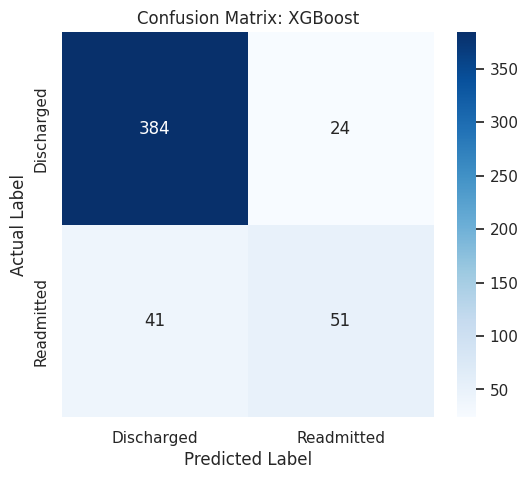

In [31]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Discharged', 'Readmitted'], yticklabels=['Discharged', 'Readmitted'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [32]:
print("\n--- DETAILED CLASSIFICATION REPORT (BEST MODEL: XGBoost) ---")
print(classification_report(y_test, results[best_model_name]["Predictions"]))


--- DETAILED CLASSIFICATION REPORT (BEST MODEL: XGBoost) ---
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       408
           1       0.68      0.55      0.61        92

    accuracy                           0.87       500
   macro avg       0.79      0.75      0.77       500
weighted avg       0.86      0.87      0.86       500

